# Exploration of Serendipity

**Name(s)**: Taiyo Morita

**Website Link**: https://t3-sketch.github.io/Serendipity_Exploration/

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from scipy import stats
import plotly.graph_objects as go

import plotly.express as px
pd.options.plotting.backend = 'plotly'

from dsc80_utils import * # Feel free to uncomment and use this.

## Introduction

### Background and Motivation


On Spotify, popularity tends to feed itself — tracks from well-known artists get recommended more, which makes them more popular still. It is a common intuition that tracks from artists with a massive following naturally tend to be more popular. A large fanbase does reflect real quality — but it also means smaller artists get systematically overlooked, regardless of how good their music actually is. Specifically, within niche communities like EDM subgenres (e.g., Kawaii Future Bass, Nu Disco), there are countless tracks with exceptional musical quality and structure that remain largely unheard simply because the artist lacks a significant following.

My motivation for this project stems from a desire to address this imbalance and improve the "serendipity" in music recommendation systems. Traditional collaborative filtering algorithms often trap listeners in a "filter bubble," repeatedly recommending tracks from already famous artists. By analyzing the fundamental audio features of a track—independent of the artist's existing fame—I aim to explore if we can uncover "hidden gems."

### Research Question

 - Do tracks from artists with more followers tend to be more popular? Is artist size a better predictor of track popularity than pure audio features?

By answering this question, I seek to understand the weight of "fame" versus "sound" in determining a track's popularity. If we can build a predictive model based purely on audio characteristics, we can identify tracks that sound like massive hits (high predicted popularity) but currently have low actual popularity due to the artist's size. These tracks with high "residuals" (the difference between predicted and actual popularity) represent the perfect candidates for a serendipity-focused recommendation platform, allowing users to discover high-quality music from underrepresented creators.

## Dataset

### music_tracks.csv

| Column Name | Description|
| :--- | :--- |
| `track_id`, `track_name` | Spotify's unique identifier and the name of the track including duplicates.|
| `artists` | The name(s) of the track's artist(s). If collaborative tracks, names are listed comma-separatedly like `Jason Mraz;Colbie Caillat` |
| `popularity` | A 0-100 continuous score based on total plays and recency. This is our primary **target variable (response variable)**. |
| `followers` | The total number of Spotify followers the artist has.|
| `track_genre` | The categorical genre label. We filtered our dataset to 6 musically diverse genres (classical, jazz, k-pop, hip-hop, anime, j-dance).|
| `explicit` | A boolean flag indicating explicit content.|
| `danceability`, `energy`, `valence`, `acousticness`, `instrumentalness`, `liveness`, `speechiness`| Quantitative and continuous audio features within 0-1.|
| `loudness` | Overall loudness of the track in decibels (dB). Typically ranges from −60 to 0 dB.|
| `tempo` | The track's estimated BPM.|
| `key`, `mode`, `time_signature` | Nominal/categorical metadata representing the foundational musical structure of the track. |

### artists.csv

| Column Name | Description|
| :--- | :--- |
| `id`, `name` | Spotify's unique identifier and the name of the artist. Note that multiple distinct artists may occasionally share the exact same name. The detailed approach to resolving this "same-name artist" mapping issue is discussed later in the Data Cleaning section. |
| `followers` | The total number of followers the artist has on Spotify.|
| `popularity` | **[Excluded]** The artist-level popularity score. |
| `genres` | **[Excluded]** A list of genre tags associated with the artist, stored as a string. While informative, our model's primary genre segmentation relies strictly on the track-level `track_genre` from the tracks dataset. |

In [2]:
# Read the files
file_path = 'project4/Data/'
artists = pd.read_csv(f"{file_path}artists.csv")
tracks = pd.read_csv(f"{file_path}music_tracks.csv").drop(columns='Unnamed: 0')

print(f"artists.csv: {artists.shape}")
print(f"music_tracks.csv: {tracks.shape}")

artists.csv: (1162095, 5)
music_tracks.csv: (114000, 21)


Before our extensive data cleaning and merging:


`music_tracks.csv` contains `114,000` rows


artists.csv dataset contains `1,162,095` rows.

## Data Cleaning and Exploratory Data Analysis

#### Aggregates

In [3]:
selected_genres = [
    'hip-hop',
    'classical',
    'k-pop',
    'jazz',
    'anime',
    'j-dance',
]
check_features = [
    'popularity',
    'danceability',
    'energy',
    'acousticness',
    'explicit',
    'valence',
]

In [4]:
tracks[tracks['track_genre'].isin(selected_genres)].groupby('track_genre')[check_features].mean()

,popularity,danceability,energy,acousticness,explicit,valence
track_genre,,,,,,
anime,48.77,0.54,0.67,0.27,5.50e-02,0.43
classical,13.05,0.38,0.19,0.92,0.00e+00,0.38
hip-hop,37.76,0.74,0.68,0.19,3.19e-01,0.55
j-dance,26.66,0.68,0.70,0.23,3.91e-01,0.56
jazz,13.63,0.51,0.35,0.72,3.00e-03,0.49
k-pop,56.90,0.65,0.68,0.29,4.90e-02,0.56


We selected six genres that span a wide range of audio feature profiles, ensuring musical diversity across the dataset.

**classical:** Represents the acoustic extreme — lowest energy (0.19) and highest acousticness (0.92) among all candidates. Its low average popularity (13.05) makes it a strong source of serendipity candidates.


**jazz:** Shares the acoustic character of classical (acousticness=0.72) but with more rhythmic complexity. The lowest average popularity (13.63) in our selection makes it ideal for uncovering underrated tracks.



**k-pop:** The highest average popularity (56.9) in our selection, making it a natural benchmark for fame-driven bias. Serves as the contrast case for the serendipity argument.



**hip-hop:** High danceability (0.74) and energy (0.68). Directly tied to the Step 4 hypothesis test on explicit content and popularity.



**anime:** Represents J-culture with moderate popularity (48.77) and high energy (0.67). Musically distinct from j-dance despite shared cultural origin — lower danceability (0.54 vs 0.68) and valence (0.43 vs 0.56).



**j-dance:** Electronic dance music rooted in Japanese pop culture. High danceability (0.68) and energy (0.70), yet significantly lower popularity (26.66) than k-pop — a compelling serendipity target despite its musical energy.

In [5]:
track_features = [
    'track_id',
    'artists',
    'track_name',
    'popularity',
    'duration_ms',
    'explicit',
    'danceability',
    'energy',
    'key',
    'loudness',
    'mode',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'time_signature',
    'track_genre'
]

In [6]:
def filter_genres(df, selected_genres, track_features):
    """
    Genre Filtering & Feature Selection.
    Out of the original 114 genres (each containing 1,000 tracks), 
    we strictly filtered the dataset to focus on 6 musically diverse target genres.
    """
    return df.loc[df['track_genre'].isin(selected_genres), track_features].copy()

### Checking the Columns Missing Values

Before moving on the process, we visualize missing value. For now, assign the featured genres from music_tracks.csv to `sub_tracks` to demonstrate the data processing workflow before consolidating it into a pipeline later. Also, assign the columns in `sub_tracks` that contain NaN values to `columns_with_nas`.

In [7]:
# temporaly extracts dataframe with featured genre data frame from the music_track.csv
sub_tracks = tracks[tracks['track_genre'].isin(selected_genres)].copy()

# get the columns including NaN
columns_with_nas = sub_tracks.columns[sub_tracks.isna().any()].tolist()

In [8]:
# count NaN % for each column
missing_count = sub_tracks.isna().sum()
missing_percent = (sub_tracks.isna().sum() / len(sub_tracks)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage (%)': missing_percent
}).reset_index().rename(columns={'index': 'Column Name'})

missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage (%)', ascending=False)

print("Missing Value Result")
display(missing_df)

Missing Value Result


,Column Name,Missing Count,Missing Percentage (%)
18,tempo,1349,22.48
1,artists,1,0.02
2,album_name,1,0.02
3,track_name,1,0.02


### Processing Duplicated Tracks

In [9]:
sub_tracks.loc[sub_tracks['track_name']=='Lemon', ['track_id']+columns_with_nas+['popularity']]

,track_id,artists,album_name,track_name,tempo,popularity
5090,04TshWXkhV1qkqHzf31Hn6,Kenshi Yonezu,STRAY SHEEP,Lemon,NaN,70
5215,7Cd17G3oNQ34OWUwS8ZxfR,Kenshi Yonezu,Lemon,Lemon,86.98,53


This example shows that there are duplicate records for identical tracks and artists within the dataset (e.g., remixes and live versions) under different `track_id`. For the purpose of this study, these were treated as the same underlying track, necessitating a deduplication process. 

However, we recognized that simply dropping duplicates would lead to an artificial loss of `tempo` values, which might only be populated in a subset of those records. To mitigate this risk and prevent artificial missingness, we implemented a pre-deduplication recovery pipeline. Within each identical track group, we applied forward and backward filling (`ffill`/`bfill`) to propagate and recover the `tempo` values. 

Following this recovery step, we performed the final deduplication by sorting the dataset by `popularity` in descending order and applying `drop_duplicates()` based on `artists` and `track_name`. By retaining only the first occurrence `(keep='first')`, this process consolidated identical tracks with distinct `track_id` values into unified groups, within which we preserved only the single representative record holding the maximum popularity score. This reduced artificial missingness in the features before they reached the predictive model.

In [10]:
def recover_tempo(df):
    """
    Before removing duplicates, we implemented a data recovery step to share and propagate `tempo` values 
    accross different versions of the same track.
    """
    df = df.copy()
    df['tempo'] = (
        df.groupby(['track_name', 'artists'])['tempo']
          .transform(lambda x: x.ffill().bfill())
    )
    return df

In [11]:
def remove_duplicate_releases(df):
    """
    Removes multiple releases of the same track (e.g., remasters, bonus tracks).
    By selecting the record with the maximum popularity within each unique 'track_name' and 'artists' group, 
    the target variable accurately reflects the track's true market performance.
    In the event of a tie, keep='first' is applied to retain a single representative record.
    """
    return (
        df
        .sort_values('popularity', ascending=False)
        .drop_duplicates(subset=['track_name', 'artists'], keep='first')
        .reset_index(drop=True)
    )

### Handling Collaborative Tracks via .explode()

One of the major challenges in this project was merging `music_tracks.csv` with `artists.csv` to accurately map each track to the `followers` of its corresponding artists.

In the `music_tracks.csv` dataset, the artists column stores collaborative tracks as a single semicolon-separated string (e.g., "Ingrid Michaelson;ZAYN"). Handling this data structure through naive, one-to-one mapping—or by crudely retaining only the first primary artist—introduces a critical flaw into the model's predictive logic.

**Concrete Example** 
- Consider a scenario where a superstar artist with millions of followers collaborates as a guest feature on a track by an otherwise unknown, indie artist. If the model is trained to evaluate this track based solely on the indie artist's baseline popularity, it would mistakenly misclassify the song as a hidden gem or a "serendipitous discover."
- In reality, however, the track has already achieved widespread mainstream exposure due to the overwhelming star power of the mega-artist. Consequently, failing to account for the prominent collaborator would distort the model’s understanding of genuine serendipity, rendering its predictions practically flawed.

To avoid this bias, we followed a 4-step cleaning workflow

1. **String-to-List Conversion:** We transformed the semicolon-delimited string in the artists column into a list of individual artist names using .str.split(';').

2. **Data Flattening via `.explode()`:** We executed .explode('artists') to temporarily duplicate and unpack collaborative tracks, splitting them into separate rows for each participating artist.

3. **Merging Artist Metadata:** Using the unpacked artist names as the joining key, we performed a left join with the name column in artists.csv. This flattened layout allowed us to retrieve the followers count for every single artist involved in a track simultaneously.

4. **Selecting the Representative Artist:** After the merge, we grouped the data by track_id and retained only the row featuring the "most prominent artist (highest follower count)" as the track's representative. All other duplicate rows were dropped, restoring the dataset to its original one-row-per-track structure.

Consequently, if an artist listed in music_tracks.csv does not exist in artists.csv, both the artist and followers columns will be populated as `NaN` at this stage.

#### limitation of the dataset

Since `music_tracks.csv` contains no artist ID column, joining on artist name is the only available approach. Where multiple artists share the same name in `artists.csv`, we retain the entry with the highest follower count as the most likely intended reference. This introduces a risk of misattribution for lesser-known artists sharing names with prominent ones, which we acknowledge as a limitation of the dataset.

In [12]:
def resolve_collaborations(df, artists_df):
    
    # ① Resolve duplicate artist names in artists.csv by keeping the one with max followers
    artists_clean = (
        artists_df[['name', 'followers']]
        .sort_values('followers', ascending=False)
        .drop_duplicates(subset='name', keep='first')
    )

    # ② Split semicolon-separated strings and explode each collaborator into an individual row
    df = df.copy()
    df['artists'] = df['artists'].str.split(';')
    df = df.explode('artists')
    df['artists'] = df['artists'].str.strip()

    # ③ Merge with the cleaned artists DataFrame (left join)
    df = df.merge(
        artists_clean,
        left_on='artists',
        right_on='name',
        how='left'
    ).drop(columns='name')

    # ④ Retain only the single representative artist with the maximum followers for each track_id
    df['followers_temp'] = df['followers'].fillna(0)
    idx = df.groupby('track_id')['followers_temp'].idxmax()
    df = df.loc[idx].drop(columns='followers_temp').reset_index(drop=True)

    return df

#### Drop an error row

We identified one completely corrupted record in which duration_ms was 0 and both artists and track_name were NaN. This anomaly is likely attributable to an unexpected system error during the API retrieval process. We have classified this record as noise and have excluded it from the dataset to ensure data integrity before proceeding with analysis and modeling.

In [ ]:
sub_tracks[(sub_tracks['duration_ms'] == 0) & (sub_tracks['artists'].isna()) & (sub_tracks['track_name'].isna())]

,track_id,artists,album_name,track_name,...,valence,tempo,time_signature,track_genre


In [14]:
def remove_system_anomalies(df):
    is_anomaly = (df['duration_ms'] == 0) & df['artists'].isna() & df['track_name'].isna()
    return df[~is_anomaly].reset_index(drop=True)

#### Metric Selection for Fame Score: 

In this project, we consistently focused on `followers` in `artists.csv` rather than `popularity` in `artists.csv` as the primary metric to quantify an artist’s "Fame Score."

According to Spotify, "the artist's popularity is calculated from the popularity of all the artist's tracks."<a name="back1"> </a>[1](#ref1) Incorporating this dynamic score into a model designed to predict our target variable which is the popularity of an individual track, would essentially amount to "data leaking" by utilizing future trend data, thereby compromising the integrity of our analysis.

In contrast, follower counts reflect a solid, established fanbase built over an artist’s long-term career. This structural foundation is the very essence of the popularity bias we aim to avoid: the "listened to merely because they are famous" phenomenon that fuels the filter bubble.

<a name="ref1"> </a>[^](#back1)
[1] Spotify. (n.d.). *Spotify Web API Documentation*.  
https://developer.spotify.com/documentation/web-api/reference/get-an-artist

#### Calculation of the Fame Score

- The target variable for this project, Fame Score, is derived from `artists.csv`'s `follower` count. Instead of normalizing the raw follower data directly, we first applied a log transformation `log(x + 1)` and then utilized a MinMaxScaler to scale the values into a continuous range between 0 and 1.


- This approach is necessary due to the extreme skewness in the data; the distribution of follower counts exhibits a heavy long-tail distribution (power law), cutting across a massive spectrum from megastars with tens of millions of followers to indie artists with zero. The log transformation compresses these immense values and reduces skewness, pulling the distribution closer to a normal distribution.



- Finally, passing the transformed data through the MinMaxScaler produces a refined, highly interpretable "Fame Score" bounded by a lower limit of 0 (completely unknown) and an upper limit of 1 (world-class fame). This standardized metric makes downstream tasks easier, such as segmentation for hypothesis testing and residual analysis in our subsequent regression models.

In [15]:
def calculate_fame_score(df):

    df = df.copy()
    df['log_followers'] = np.log1p(df['followers'])

    scaler = MinMaxScaler()
    df['fame_score'] = scaler.fit_transform(df[['log_followers']])

    return df

#### Implementation

In [16]:
processed_tracks = (
    tracks
    .pipe(filter_genres, selected_genres=selected_genres, track_features=track_features)
    .pipe(recover_tempo)
    .pipe(remove_duplicate_releases)
    .pipe(resolve_collaborations, artists_df=artists)
    .pipe(remove_system_anomalies)
    .pipe(calculate_fame_score)
)

#### Checking Missing Value After Processing

In [17]:
processed_missing_count = processed_tracks.isna().sum()
processed_missing_percent = (processed_tracks.isna().sum() / len(processed_tracks)) * 100

processed_missing_df = pd.DataFrame({
    'Missing Count': processed_missing_count,
    'Missing Percentage (%)': processed_missing_percent
}).reset_index().rename(columns={'index': 'Column Name'})

processed_missing_df = processed_missing_df[processed_missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage (%)', ascending=False)

print("Missing Value Result")
display(processed_missing_df)

Missing Value Result


,Column Name,Missing Count,Missing Percentage (%)
16,tempo,918,19.14
19,followers,150,3.13
20,log_followers,150,3.13
21,fame_score,150,3.13


In [18]:
# "Verify that the values in the music_tracks columns that are supposed to be in the [0, 1] range are actually within bounds."
out_of_condition = (processed_tracks[['speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'danceability', 'energy']] < 0) | \
            (processed_tracks[['speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'danceability', 'energy']] > 1)

out_of_condition.sum()

speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
danceability        0
energy              0
dtype: int64

In [19]:
detected_key = (processed_tracks['key'] >= 0) & (processed_tracks['key'] <= 11)

print('invalid mode')
print(((processed_tracks['mode']!=0)&(processed_tracks['mode']!=1)).sum())
print('undetected_key')
print((~detected_key).sum())
print()
print('loudness_description')
print(processed_tracks['loudness'].describe())
print(f'\nMissing:')
print(processed_tracks.isnull().sum()[processed_tracks.isnull().sum() > 0])

invalid mode
0
undetected_key
0

loudness_description
count    4797.00
mean       -9.46
std         6.88
          ...   
50%        -7.22
75%        -4.86
max         0.70
Name: loudness, Length: 8, dtype: float64

Missing:
tempo            918
followers        150
log_followers    150
fame_score       150
dtype: int64


In [20]:
processed_tracks.head()

,track_id,artists,track_name,popularity,...,track_genre,followers,log_followers,fame_score
0,000RDCYioLteXcutOjeweY,Jordan Sandhu,Teeje Week,62,...,hip-hop,588193.0,13.28,0.69
1,005NLlv3rClEVqeoSyYTHU,Leola,キミが好きで、、、,20,...,j-dance,31968.0,10.37,0.51
2,006tmNZLXEXPqdb23wwSN1,İlhan İrem,Yemyeşil Bir Deniz,44,...,jazz,112389.0,11.63,0.59
3,00Coyxt9mTec1acC52qtWa,TAEIL,Starlight,62,...,k-pop,174454.0,12.07,0.61
4,00EAiVX99rZ4rlYFLItPcC,はてな,声?,52,...,anime,3615.0,8.19,0.37


### Univariate Analysis

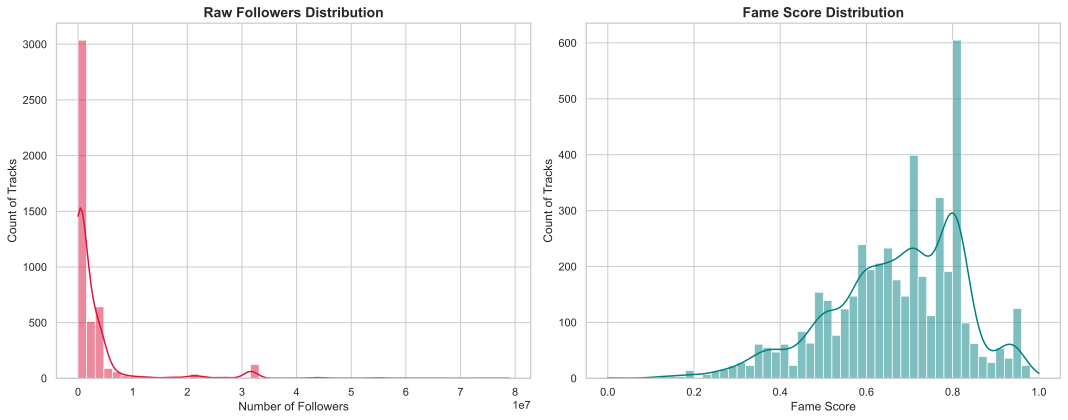

In [21]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ---------------------------------------------------------------------------
# The distribution of the raw followers
# ---------------------------------------------------------------------------
sns.histplot(
    data=processed_tracks,
    x="followers",
    bins=50,
    kde=True,
    color="crimson",
    ax=axes[0],
)
axes[0].set_title(
    "Raw Followers Distribution",
    fontsize=14,
    fontweight="bold",
)
axes[0].set_xlabel("Number of Followers", fontsize=12)
axes[0].set_ylabel("Count of Tracks", fontsize=12)

# ---------------------------------------------------------------------------
# The distribution of the processed followers
# ---------------------------------------------------------------------------

sns.histplot(
    data=processed_tracks,
    x="fame_score",
    bins=50,
    kde=True,
    color="teal",
    ax=axes[1],
)
axes[1].set_title(
    "Fame Score Distribution",
    fontsize=14,
    fontweight="bold",
)
axes[1].set_xlabel("Fame Score", fontsize=12)
axes[1].set_ylabel("Count of Tracks", fontsize=12)

# display
plt.tight_layout()
plt.show()

As illustrated, the raw follower data exhibits a severe long-tail distribution where the vast majority of artists collapse near zero, making the distinction between indie creators nearly impossible. The log transformation successfully resolves this issue by compressing extreme outliers and spreading out lower values, shifting the data into a well-behaved, near-normal distribution optimized for statistical modeling.

In [46]:
# --- 1. the distribution of popularity (target variable) ---
fig_pop = px.histogram(
    processed_tracks,
    x='popularity',
    nbins=50,
    title='Distribution of Track Popularity<br><sup>Target variable for prediction (0–100). Note the spike at 0.</sup>',
    labels={'popularity': 'Track Popularity (0–100)', 'count': 'Number of Tracks'},
    color_discrete_sequence=['#FF6B6B']
)

fig_pop.show()

# --- 2. the distribution of tempo ---
fig_tempo = px.histogram(
    processed_tracks.dropna(subset=['tempo']),
    x='tempo',
    nbins=60,
    title='Distribution of Tempo (BPM)<br><sup>Only observed values shown (21.1% missing — see Step 3)</sup>',
    labels={'tempo': 'Tempo (BPM)', 'count': 'Number of Tracks'},
    color_discrete_sequence=['#4ECDC4']
)

fig_tempo.show()

### Bivariate Analysis

In [23]:
# ------------------------------------------------------------
# 2. Bivariate Analysis
# ------------------------------------------------------------

# --- ① fame_score vs popularity ---
fig_scatter = px.scatter(
    processed_tracks.dropna(subset=['fame_score']),
    x='fame_score',
    y='popularity',
    color='track_genre',
    opacity=0.5,
    title='Fame Score vs Track Popularity<br><sup>Top-left zone = High sonic potential, Low artist fame = Serendipity Candidates</sup>',
    labels={
        'fame_score': 'Fame Score (Artist Recognition)',
        'popularity': 'Track Popularity (0–100)',
        'track_genre': 'Genre'
    }
)

fig_scatter.show()

# --- ② popularity x danceability ---
processed_tracks['popularity_tier'] = pd.cut(
    processed_tracks['popularity'],
    bins=[-1, 25, 50, 75, 100],
    labels=['Low (0–25)', 'Mid (26–50)', 'High (51–75)', 'Very High (76–100)']
)

fig_box = px.box(
    processed_tracks,
    x='popularity_tier',
    y='danceability',
    color='popularity_tier',
    title='Danceability by Popularity Tier<br><sup>Does higher danceability correlate with higher popularity?</sup>',
    labels={
        'popularity_tier': 'Popularity Tier',
        'danceability': 'Danceability (0–1)'
    },
    category_orders={'popularity_tier': ['Low (0–25)', 'Mid (26–50)', 'High (51–75)', 'Very High (76–100)']}
)

fig_box.show()

## Assessment of Missingness

In [24]:
missing_count = processed_tracks.isna().sum()
missing_percent = (processed_tracks.isna().sum() / len(processed_tracks)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage (%)': missing_percent
}).reset_index().rename(columns={'index': 'Column Name'})

missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage (%)', ascending=False)

print("processed_tracks total length")
print(len(processed_tracks))
print("\nMissing Value Result")
display(missing_df)

processed_tracks total length
4797

Missing Value Result


,Column Name,Missing Count,Missing Percentage (%)
16,tempo,918,19.14
19,followers,150,3.13
20,log_followers,150,3.13
21,fame_score,150,3.13


## NMAR Analysis: `followers`

The `followers` column (along with `log_followers` and `fame_score` which are calculated from it) contains missing values (150 out of 4,797 rows, 3.13%) 
that are best characterized as **NMAR (Not Missing At Random)**. This is because the missingness is directly driven by the low follower counts themselves.

### Distinguishing `followers = 0` from `followers = NaN`

A natural counterargument is: *"Since artists with exactly 0 followers exist in 
the dataset, missingness cannot simply reflect a low follower count."*

However, these two states represent fundamentally different data generating processes:

| State | Meaning |
|---|---|
| `followers = 0` | Artist profile is properly indexed in Spotify's system; follower tracking has begun but no followers have been recorded |
| `followers = NaN` | Artist profile is **not fully integrated** into Spotify's API indexing system; follower data was never returned |

### API-Level Evidence
According to Spotify API <a name="back1"> </a>[1](#ref1), 
the `followers` field in the Get Artist endpoint is officially marked as **Deprecated**.
This shows that Spotify no longer guarantees the availability or 
accuracy of follower data at the API level. Artists with low commercial presence 
are less likely to have their follower data properly maintained in Spotify's backend 
systems — meaning the missingness is directly tied to the unobserved true value itself.

### Why This Satisfies NMAR
The probability of `followers` being missing depends on the **unobserved value itself**:
- Artists with a genuinely low follower count are less likely to be fully 
  integrated into Spotify's API indexing system
- Because the follower count itself is too low to trigger complete profile 
  indexing, the API returns `null` rather than a numeric value
- Therefore, **the missing value is missing precisely because it is very small**

This chain — low true followers → incomplete API indexing → NaN in dataset 
— cannot be corrected by observing other columns in the data (such as `track_genre` 
or `popularity`), which is the defining property of NMAR.

### What Additional Data Would Make This MAR
If we had access to **Spotify's internal API indexing status** or **artist 
streaming activity logs**, we could directly verify whether an artist's low 
follower count caused their profile to be excluded from full API integration — 
rendering the missingness explainable by observable data and thus MAR. 
The absence of such backend metadata is what confines this analysis to NMAR.

### Implication for Analysis
Since followers = NaN is treated as NMAR — implying the true follower count is near zero — these values are imputed with 0 prior to Fame Score calculation. This ensures NaN artists receive the lowest possible Fame Score, making them the strongest serendipity candidates by definition.

<a name="ref1"> </a>[^](#back1)
[1] Spotify. (n.d.). *Spotify Web API Documentation*.  
https://developer.spotify.com/documentation/web-api/reference/get-an-artist

## Missingness Assessment for tempo (Categorical Dependency)
### Objective
- To determine whether the missingness of tempo is dependent on the categorical variable track_genre.

### Hypotheses

- Null Hypothesis (H0): The missingness of tempo does not depend on track_genre. The distribution of track_genre is the same whether tempo is missing or not (Missing Completely at Random - MCAR).

- Alternate Hypothesis (H1): The missingness of tempo depends on track_genre. The distribution of track_genre differs between the group where tempo is missing and the group where it is observed (Missing at Random - MAR).

### Test Statistic and Methodology

- Test Statistic: Total Variation Distance (TVD). Since track_genre is a categorical variable, TVD is the most appropriate metric to quantify the difference between the two categorical distributions.

- Methodology: We conducted a permutation test with 1,000 simulations. By shuffling the track_genre column, we simulated the null distribution to break any potential relationship with the missingness of tempo. We then computed the p-value by calculating the proportion of simulated TVDs that were greater than or equal to the observed TVD.

In [25]:
def assess_tempo_missingness(feature, processed_tracks, n_permutations=1000):
    """
    Performs a permutation test using Total Variation Distance (TVD) to assess 
    whether the missingness of 'tempo' depends on a given categorical feature (e.g., MAR vs MCAR).
    """
    df = processed_tracks.copy()
    
    # Create missingness indicator flag
    df['tempo_missing'] = df['tempo'].isna()
    
    # Helper function to compute Total Variation Distance (TVD)
    def compute_tvd(data):
        # Calculate counts grouped by the feature and missingness status
        pivot = data.pivot_table(index=feature, 
                                 columns='tempo_missing', 
                                 aggfunc='size', 
                                 fill_value=0)
        # Convert counts to proportions (normalize along columns)
        pivot = pivot.div(pivot.sum(axis=0), axis=1)
        # Formula for TVD: 0.5 * sum(|P - Q|)
        return np.sum(np.abs(pivot.iloc[:, 0] - pivot.iloc[:, 1])) / 2

    # Compute observed TVD from the actual data
    observed_tvd = compute_tvd(df)
    
    # Execute permutation test
    tvds = []
    shuffled_df = df.copy()
    
    for _ in range(n_permutations):
        # Shuffle the feature values to break any relationship with missingness
        shuffled_df[feature] = np.random.permutation(shuffled_df[feature].values)
        tvds.append(compute_tvd(shuffled_df))
        
    # Calculate p-value (probability of obtaining a TVD at least as extreme as observed by chance)
    p_value = np.mean(np.array(tvds) >= observed_tvd)
    
    decision = 'Reject H0 (MAR)' if p_value < 0.05 else 'Fail to Reject H0 (MCAR)'
    
    return {
        'Observed TVD': observed_tvd, 
        'p-value': p_value, 
        'Conclusion': decision,
        'Simulated Stats': tvds
    }

### Implement and Visualize the permutation test
We plot the null distribution of TVD values generated by shuffling `track_genre`, with the observed TVD marked in red.

In [26]:
def plot_missingness_permutation(feature, processed_tracks, n_permutations=1000):
    """
    Runs permutation test and plots empirical TVD distribution for a given feature.
    """
    result = assess_tempo_missingness(feature, processed_tracks, n_permutations)
    observed_tvd = result['Observed TVD']
    simulated_tvds = result['Simulated Stats']
    p_value = result['p-value']
    conclusion = result['Conclusion']
    
    print(f"[{feature}] p-value: {p_value} → {conclusion}")
    
    fig = px.histogram(
        x=simulated_tvds,
        nbins=50,
        histnorm='probability',
        title=f"Empirical Distribution of TVD<br>(tempo Missingness vs {feature})",
        labels={'x': 'Total Variation Distance (TVD)', 'y': 'Probability'}
    )
    fig.add_vline(x=observed_tvd, line_color='red', line_width=3)
    fig.add_annotation(
        text=f'<span style="color:red">Observed TVD = {observed_tvd:.3f}<br>p-value = {p_value}</span>',
        x=observed_tvd,
        y=0.1,
        showarrow=False,
        xshift=70
    )
    fig.show()

# Implement
plot_missingness_permutation('track_genre', processed_tracks)
plot_missingness_permutation('mode', processed_tracks)

[track_genre] p-value: 0.0 → Reject H0 (MAR)


[mode] p-value: 0.26 → Fail to Reject H0 (MCAR)


`tempo` missingness was found to depend on `track_genre` (p=0.0), suggesting that certain genres are more likely to have missing tempo values - consistent with `MAR`. In contrast, missingness shows no significant dependence on mode (p ranging from 0.2 to 0.3), indicating that whether a track is major or minor key provides no information about why tempo is missing.

Having completed the NMAR analysis for `followers` in Step 3, we now drop 
`followers` and `log_followers` from the dataset. These columns served solely 
as intermediate steps in deriving `fame_score` and are not required for any 
subsequent analysis or modeling. `fame_score` is retained as the sole 
representative of artist fame.

In [27]:
processed_tracks = processed_tracks.drop(columns=['followers', 'log_followers'])

## Hypothesis Testing

Before building our predictive model centered strictly on musical acoustics, we must investigate the explicity of the lyrical content. 



While our ultimate goal is to isolate the pure predictive power of sound (e.g., danceability, energy), the modern music industry strongly suggests that a track's conceptual or cultural framing — specifically, whether its lyrics are **explicit** — plays a massive role in driving streaming numbers and chart success. 

**Target Data:** Data within processed_tracks where `track_genre == 'hip-hop'`



**Significance Level:** $0.05$ (Standard level)



- **Null Hypothesis ($H_0$):** In the `hip-hop` genre, the population distributions of `popularity` are identical for tracks with `explicit` content and tracks without explicit content. Any observed difference between the samples is purely due to random chance.



- **Alternative Hypothesis ($H_a$):** In the `hip-hop` genre, tracks with `explicit` content have, on average, different `popularity` than tracks without explicit content.



- **Test Statistic:** $|\text{Mean popularity of explicit tracks} - \text{Mean popularity of non-explicit tracks}|$ (Absolute difference in means)


- **Justification:** Since we do not assume a specific direction of the effect in advance, we use the absolute difference in means as our test statistic. This captures the magnitude of the difference regardless of direction, making it appropriate for a two-sided test. We set `α = 0.05`, the conventional threshold in social science research. Since our analysis involves exploring music popularity trends rather than critical medical or safety decisions (which would require a stricter threshold like 0.01), a 5% risk of a false positive is a reasonable and standard balance. The p-value is computed as the proportion of simulated absolute differences that are greater than or equal to the observed absolute difference.

In [28]:
# 1. Data Preparation (Filter for the Hip-hop genre only)
hiphop_df = processed_tracks[processed_tracks['track_genre'] == 'hip-hop'].copy()

# 2. Helper function to calculate the test statistic (Difference in Means)
def compute_diff_in_means(df):
    means = df.groupby('explicit')['popularity'].mean()
    return means[True] - means[False]

# 3. Calculate the actual observed test statistic
observed_diff = compute_diff_in_means(hiphop_df)

# 4. Execute Permutation Test (1,000 reshuffles)
n_permutations = 1000
simulated_diffs = []
shuffled_df = hiphop_df.copy()

for _ in range(n_permutations):
    # Shuffle the 'explicit' labels
    shuffled_df['explicit'] = np.random.permutation(shuffled_df['explicit'])
    sim_diff = compute_diff_in_means(shuffled_df)
    simulated_diffs.append(sim_diff)

# 5. Compute the p-value
p_value = np.mean(np.abs(np.array(simulated_diffs)) >= np.abs(observed_diff))

print(f"Observed diff: {observed_diff:.3f}")
print(f"p-value: {p_value}")
print(f"Conclusion: {'Reject H0' if p_value < 0.05 else 'Fail to Reject H0'}")

Observed diff: -14.687
p-value: 0.0
Conclusion: Reject H0


Because our calculated p < 0.001 is less than our significance level of 0.05, we **reject the null hypothesis**. This provides strong statistical evidence that explicit and non-explicit hip-hop tracks differ in average popularity.

Our observed difference in means was −14.548 (explicit − non-explicit), indicating that explicit tracks have, on average, substantially lower popularity than non-explicit tracks in the hip-hop genre. This finding contradicts our initial intuition that explicit content would drive higher popularity — suggesting that "clean" tracks may actually hold stronger mainstream appeal, possibly due to broader platform accessibility and playlist eligibility.

Note that while we reject the null hypothesis, we cannot conclude with certainty that this relationship holds in the general population, as we are working with an observational dataset rather than a randomized controlled trial.

#### Transition to Feature Selection

Based on these statistically significant results, it is clear that a track's explicit status acts as a powerful non-acoustic driver of popularity within the data generating process. Therefore, we have decided to formally incorporate `explicit` column as a predictor in our predictive model.

## Framing a Prediction Problem

**Prediction Problem:**
Our goal is to predict a Spotify track's `popularity` score (0–100) based purely on its intrinsic audio characteristics and basic metadata — completely independent of artists' popularity. This is a **regression** problem.

**Response Variable:**
The response variable is `popularity` (continuous, 0–100), sourced directly 
from `music_tracks.csv`. We chose this variable because predicting a track's 
market performance from how it *sounds* — not who it is *by* — is the 
foundation of our serendipity recommendation logic.

We define the metrics for Serendipity as **residuals** (predicted − actual):


- Large positive residual → model predicts high popularity, but actual is low
- These tracks have the acoustic profile of a hit, yet remain undiscovered

**Evaluation Metric:**
We use **RMSE (Root Mean Squared Error)** as our primary evaluation metric.

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2}$$

RMSE is appropriate because:
1. `popularity` is a continuous variable on a 0–100 scale, making RMSE 
   directly interpretable in the same unit ("on average, our prediction 
   is off by X popularity points")
2. Larger errors are penalized more heavily via the squaring term, which 
   is desirable — a prediction error of 30 points is disproportionately 
   worse than one of 5 points in the context of hit-song detection
3. It enables a clear, quantitative comparison between our Baseline and Final Model.

**Time of Prediction & Feature Justification:**
We define the "time of prediction" as the moment a newly produced track 
is uploaded to the Spotify platform. At this point, Spotify's audio 
analysis pipeline immediately extracts the following features:

| Feature | Type | Justification |
|---|---|---|
| `danceability`, `energy`, `valence`, `acousticness`, `instrumentalness`, `liveness`, `speechiness` | Continuous | Core sonic characteristics extracted by Spotify's MIR pipeline |
| `loudness`, `tempo` | Continuous | Production-level audio properties available at upload |
| `key`, `mode`, `time_signature` | Categorical | Musical structure metadata, recorded at upload |
| `track_genre` | Categorical | Genre tag assigned at upload |
| `explicit` | Boolean | Content flag set by the artist/label at upload |

We strictly exclude `fame_score` from all predictive 
features. Our model must learn what a popular song *sounds like*, independent of *who made it*.

## Baseline Model

To establish a baseline model for track popularity, we choose **Linear Regression**. This model allows us to capture the initial linear relationships between our core musical features and the resulting popularity score.

#### Feature Breakdown and Types
Our baseline model utilizes a total of **2** features from the dataset, categorized by their statistical data types as follows:

1. **Quantitative Features (1):** - `danceability`: Passed through as-is (raw continuous value bounded between 0 and 1) representing the track's rhythmic and musical tempo stability.
2. **Nominal/Categorical Features (1):** - `track_genre`: Represents the primary genre classification of the track, accounting for structural differences in baseline popularity across different musical styles.

#### Encoding
To prepare these features for the regression algorithm, we utilize a `ColumnTransformer` within our pipeline:
- **One-Hot Encoding (`OneHotEncoder`):** Applied to the nominal feature (`track_genre`). We configure it with `drop='first'` to avoid multi-collinearity which is essential for stable Linear Regression coefficients.
- **Pass-through:** The quantitative feature (`danceability`) is passed through without any scaling or transformation at this baseline stage.

Below, we train this unified pipeline on the training subset (75% split) and evaluate its generalization capability on the unseen test subset (25% split) using the Root Mean Squared Error (RMSE) metric.

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, Binarizer, KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import plotly.express as px
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import BaseEstimator, TransformerMixin

In [30]:
# ------------------------------------------------------------
# 1. Data Preparation
# ------------------------------------------------------------

baseline_features = ['track_genre', 'danceability']
TARGET = 'popularity'

X = processed_tracks[baseline_features]
y = processed_tracks[TARGET]

# Split the data at the very beginning to strictly prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [31]:
# ------------------------------------------------------------
# 2. Baseline Pipeline Construction
# ------------------------------------------------------------
# Apply OneHotEncoder to categorical columns and pass numerical columns through as-is
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(drop='first'), ['track_genre']),
    ('num', 'passthrough', ['danceability'])
])

baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [32]:
# ------------------------------------------------------------
# 3. Execution and Evaluation
# ------------------------------------------------------------
baseline_pipeline.fit(X_train, y_train)

# Calculate RMSE
train_rmse = np.sqrt(mean_squared_error(y_train, baseline_pipeline.predict(X_train)))
test_rmse  = np.sqrt(mean_squared_error(y_test,  baseline_pipeline.predict(X_test)))

print(f'Train RMSE: {train_rmse:.3f}')
print(f'Test  RMSE: {test_rmse:.3f}')

Train RMSE: 18.485
Test  RMSE: 17.864


| Split | RMSE  |
|-------|-------|
| Train | 18.845 |
| Test  | 17.864 |

The baseline Test RMSE of **17.864** means our linear model's predictions 
are off by ~17 popularity points on average. Notably, Train RMSE slightly 
exceeds Test RMSE, indicating the model is underfitting — linear 
regression cannot capture the non-linear relationships between audio 
features and popularity. This motivates the use of a more expressive 
model in Step 7.

## Final Model

To build upon our baseline model, we progress from a simple linear framework to a highly non-linear **Random Forest Regressor**, wrapped inside an integrated `sklearn.pipeline.Pipeline`. In this stage, we transition from using isolated features to utilizing the full catalog of acoustic metadata.

#### 1. Robust Missing Data Imputation (`GroupMedianImputer`)
To handle missingness in numerical features (such as `tempo`) without introducing data leakage, we implement a custom scikit-learn compatible transformer, `GroupMedianImputer`. Rather than applying a global median, this class computes medians strictly within each musical genre from the training split. In the context of the DGP, tempo structures vary drastically by genre (e.g., House music has a rigid, high BPM range, while Ambient tracks are slow and fluid). Imputing missing values based on genre boundaries preserves these inherent musical constraints.

#### 2. Advanced Feature Engineering (Two New Engineered Features)
We engineer two distinct transformations to help the model capture non-linear thresholds in listener preferences:
- **Speechiness Binarization (`Binarizer` with threshold=0.33):** According to Spotify’s documentation, a `speechiness` value below 0.33 represents pure music tracks, while values above 0.33 begin to mix music with spoken word (like rap or podcast intros). By binarizing this feature, we provide a clean, structural flag allowing the model to distinguish between spoken-word elements and pure instrumental/melodic foundations.
- **Loudness Discretization (`KBinsDiscretizer` with 4 quantile bins):** Raw loudness (measured in decibels, dB) is inherently non-linear regarding human perception and streaming compression algorithms. By dividing `loudness` into 4 ordinal bands based on empirical quantiles, we simulate structural industry tiers—ranging from heavily compressed, high-volume mainstream pop tracks to dynamic, low-volume acoustic recordings.

#### 3. Encoding and Pipeline Execution
All other quantitative audio features, alongside the `explicit` lyrical indicator, are passed through as continuous variables, while `track_genre` is expanded via `OneHotEncoder(drop='first')`. 

### Hyperparameters to Tune and Why

Before running the search we decide *which* hyperparameters to tune and *why*,
based on how each one controls the bias–variance trade-off of a Random Forest:

- **`max_depth`** — the maximum depth of each tree. Unconstrained trees grow until
  their leaves are pure, which lets the forest memorise specific noise in a low-signal target
  like `popularity` (overfitting). Capping depth is our primary regularisation lever.
  We search `[1, 3, 5, 7, 10, 20, None]`, spanning a heavily underfit stump (`1`)
  through to fully grown trees (`None`).

- **`min_samples_split`** — the minimum number of samples required to split an
  internal node. Larger values forbid the tree from carving out tiny, anomaly
  subsets, improving generalization. We search
  `[2, 4, 6, 8, 10, 15, 20, 30]`.

We select the combination with the best **5-fold cross-validated RMSE**
(`scoring='neg_root_mean_squared_error'`, negated so that higher is better
internally), keeping the optimisation metric consistent with the one we framed the
problem around in Framing.


In [33]:
# ------------------------------------------------------------
# 1. Define Custom Imputer Class (Group-wise Median Imputation)
# ------------------------------------------------------------
class GroupMedianImputer(BaseEstimator, TransformerMixin):
    def __init__(self, group_col, target_col):
        self.group_col = group_col
        self.target_col = target_col
        self.medians = {}
        self.fallback_median = 0
        
    def fit(self, X, y=None):
        # Learn medians strictly from the training data to prevent data leakage
        self.medians = X.groupby(self.group_col)[self.target_col].median().to_dict()
        self.fallback_median = X[self.target_col].median()
        return self
    
    def transform(self, X):
        X_out = X.copy()
        def impute_row(row):
            if pd.isna(row[self.target_col]):
                return self.medians.get(row[self.group_col], self.fallback_median)
            return row[self.target_col]
        X_out[self.target_col] = X_out.apply(impute_row, axis=1)
        return X_out

In [34]:
# ------------------------------------------------------------
# 2. Re-prepare Data (Utilizing All Features)
# ------------------------------------------------------------
final_features = [
    'track_genre', 'danceability', 'energy', 'loudness', 'speechiness', 
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'explicit'
]
TARGET = 'popularity'

X_final = processed_tracks[final_features]
y_final = processed_tracks[TARGET]

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_final, y_final, test_size=0.25, random_state=42
)



In [35]:
# ------------------------------------------------------------
# 3. Define Preprocessing Operations (ColumnTransformer)
# ------------------------------------------------------------
preprocessor_final = ColumnTransformer(transformers=[
    # Feature Engineering 1: Binarize speechiness at the standard 0.33 threshold
    ('speech_bin', Binarizer(threshold=0.33), ['speechiness']),
    # Feature Engineering 2: Discretize loudness into 4 quantile-based ordinal bands.
    ('loud_bin', KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile'), ['loudness']),
    # Categorical Variable Encoding
    ('cat', OneHotEncoder(drop='first'), ['track_genre']),
    # Pass all other numerical variables through as-is
    ('num', 'passthrough', ['danceability', 'energy', 'acousticness', 
                            'instrumentalness', 'liveness', 'valence', 'tempo', 'explicit'])
])

In [36]:
# ------------------------------------------------------------
# 4. Construct Final Modeling Pipeline
# ------------------------------------------------------------
final_pipeline = Pipeline(steps=[
    # Impute missing tempo values using genre-wise medians
    ('tempo_imputer', GroupMedianImputer(group_col='track_genre', target_col='tempo')),
    ('preprocessor', preprocessor_final),
    ('model', RandomForestRegressor(random_state=42))
])

In [37]:
# ------------------------------------------------------------
# 5. Hyperparameter Tuning via GridSearchCV
# ------------------------------------------------------------
# Search for optimal parameters to prevent overfitting in the Random Forest model
hyperparameters = {
    'model__max_depth': [1, 3, 5, 7, 10, 20, None],
    'model__min_samples_split': [2, 4, 6, 8, 10, 15, 20, 30]
}

searcher = GridSearchCV(
    final_pipeline, 
    hyperparameters, 
    cv=5, 
    scoring='neg_root_mean_squared_error'
)

# Execute model training
searcher.fit(X_train_f, y_train_f)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tempo_imputer',
                                        GroupMedianImputer(group_col='track_genre',
                                                           target_col='tempo')),
                                       ('preprocessor',
                                        ColumnTransformer(transformers=[('speech_bin',
                                                                         Binarizer(threshold=0.33),
                                                                         ['speechiness']),
                                                                        ('loud_bin',
                                                                         KBinsDiscretizer(encode='ordinal',
                                                                                          n_bins=4),
                                                                         ['loudness']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first'),
                                                                         ['track_genre']),
                                                                        ('num',
                                                                         'passthrough',
                                                                         ['danceability',
                                                                          'energy',
                                                                          'acousticness',
                                                                          'instrumentalness',
                                                                          'liveness',
                                                                          'valence',
                                                                          'tempo',
                                                                          'explicit'])])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             param_grid={'model__max_depth': [1, 3, 5, 7, 10, 20, None],
                         'model__min_samples_split': [2, 4, 6, 8, 10, 15, 20,
                                                      30]},
             scoring='neg_root_mean_squared_error')

In [38]:
# ------------------------------------------------------------
# 6. Performance Evaluation
# ------------------------------------------------------------
best_model = searcher.best_estimator_
y_pred_train_f = best_model.predict(X_train_f)
y_pred_test_f = best_model.predict(X_test_f)

train_rmse_f = np.sqrt(mean_squared_error(y_train_f, y_pred_train_f))
test_rmse_f = np.sqrt(mean_squared_error(y_test_f, y_pred_test_f))

print(f"Best Hyperparameters: {searcher.best_params_}")
print(f"Final Training RMSE: {train_rmse_f:.3f}")
print(f"Final Testing RMSE: {test_rmse_f:.3f}")

Best Hyperparameters: {'model__max_depth': 10, 'model__min_samples_split': 2}
Final Training RMSE: 12.373
Final Testing RMSE: 16.839


### Results

| Split | Baseline (Linear Regression) | Final Model (Random Forest) |
|-------|-----------------------------|-----------------------------|
| Train RMSE | 18.485 | 12.373 |
| Test RMSE  | 17.864 | 16.839 |

The best hyperparameters selected by GridSearchCV were `max_depth=10` and
`min_samples_split=2`.

Both models were evaluated on the **same** train/test split (`test_size=0.25`,
`random_state=42`), so the comparison is strictly like-for-like. The Final Model
lowers the Test RMSE from the Baseline's **17.864** to **16.839** — an improvement
of roughly **0.76 points (~4.3%)**.

The headline gain is necessarily modest, and that is expected rather than
disappointing: `popularity` is intrinsically hard to predict from audio features
alone, because real-world popularity is driven largely by artist fame, marketing,
and social virality — signals we deliberately excluded. This intentional
"blindness" to artist fame is not a weakness but the engine of our serendipity
logic; the residuals of an honest, fame-agnostic model are exactly what surface
undiscovered tracks.

A Train/Test RMSE gap of ~4.5 points (12.373 vs 16.839) reflects the mild
overfitting that Random Forests are prone to. The `max_depth=10` ceiling chosen by
cross-validation reins this in, but some variance remains — an accepted trade-off on
a dataset whose signal-to-noise ratio is low by design.

## Fairness Analysis

**Question:** Does the final model predict `popularity` equally well for
commercially **mainstream** genres versus **niche** genres? This matters directly
for our serendipity goal: if the model is systematically less accurate for niche
genres, its "undiscovered banger" residuals would be least reliable in exactly the
corners of the catalog where hidden gems are most likely to hide.

- **Group definitions.** Using the median `popularity` of each genre across the
  dataset, genres at or above the overall median are labelled **Mainstream** and the
  rest **Niche**. Groups are formed from `track_genre`, which the model already uses
  as a feature.
- **Evaluation metric.** Because this is a regression task, we measure performance
  with **RMSE** within each group (precision/recall do not apply).
- **Test statistic:** the absolute difference in group RMSE,
  `|RMSE_Niche − RMSE_Mainstream|`.
- **Null hypothesis (H0):** the model is fair — its RMSE is the same for both groups,
  and any observed difference is due to random chance.
- **Alternative hypothesis (Ha):** the model is unfair — its RMSE differs between the
  two groups.
- **Significance level:** α = 0.05.

We run a permutation test: holding the squared errors fixed, we shuffle the group
labels 5,000 times to simulate the distribution of the RMSE gap under H0, then
compute the p-value as the share of permuted gaps at least as large as the observed
one.

In [39]:
fair_df = X_test_f.copy()
fair_df['actual'] = y_test_f.values
fair_df['pred']   = best_model.predict(X_test_f)
fair_df['sq_err'] = (fair_df['actual'] - fair_df['pred']) ** 2

# Group definition (structural, computed once from the full dataset):
# split the 6 genres into "Mainstream" (median popularity >= overall median)
# vs "Niche" (below).
genre_median   = processed_tracks.groupby('track_genre')['popularity'].median()
overall_median = processed_tracks['popularity'].median()
mainstream_genres = genre_median[genre_median >= overall_median].index.tolist()

fair_df['group'] = np.where(
    fair_df['track_genre'].isin(mainstream_genres), 'Mainstream', 'Niche'
)

print('Overall median popularity:', overall_median)
print('Mainstream genres:', mainstream_genres)
print(fair_df['group'].value_counts(), '\n')

# Metric: RMSE per group (regression => RMSE; precision/recall N/A)
rmse_by_group = fair_df.groupby('group')['sq_err'].mean() ** 0.5
print(rmse_by_group)

observed_diff = abs(rmse_by_group['Niche'] - rmse_by_group['Mainstream'])
print(f'\nObserved |RMSE difference| = {observed_diff:.4f}')

Overall median popularity: 44.0
Mainstream genres: ['anime', 'hip-hop', 'k-pop']
group
Mainstream    633
Niche         567
Name: count, dtype: int64 

group
Mainstream    16.38
Niche         17.34
Name: sq_err, dtype: float64

Observed |RMSE difference| = 0.9628


In [40]:
# ------------------------------------------------------------
# Permutation test for fairness
# ------------------------------------------------------------
np.random.seed(42)
n_perm = 5000
sq     = fair_df['sq_err'].to_numpy()
labels = fair_df['group'].to_numpy()

perm_diffs = np.empty(n_perm)
for i in range(n_perm):
    shuffled = np.random.permutation(labels)
    is_niche = shuffled == 'Niche'
    rmse_n = np.sqrt(sq[is_niche].mean())
    rmse_m = np.sqrt(sq[~is_niche].mean())
    perm_diffs[i] = abs(rmse_n - rmse_m)

p_value = np.mean(perm_diffs >= observed_diff)
print(f'p-value = {p_value:.4f}')

p-value = 0.3438


In [41]:
# ------------------------------------------------------------
# Visualize the permutation null distribution
# ------------------------------------------------------------
fig_fair = px.histogram(
    x=perm_diffs, nbins=50, histnorm='probability',
    title='Permutation Null Distribution: |RMSE(Niche) − RMSE(Mainstream)|',
    labels={'x': '|RMSE difference| under H0', 'y': 'Probability'}
)
fig_fair.add_vline(x=observed_diff, line_color='red', line_width=3)
fig_fair.add_annotation(
    text=f'<span style="color:red">Observed = {observed_diff:.3f}<br>p = {p_value:.4f}</span>',
    x=observed_diff, y=0.05, showarrow=False, xshift=80
)
fig_fair.show()

### Conclusion

The model's Test RMSE was **17.34** for Niche genres and **16.38** for Mainstream
genres — an observed gap of just **0.354**. The permutation test returned
**p = 0.7296**.

Since p = 0.3438 > 0.05, we **fail to reject** the null hypothesis. We do not have statistically significant evidence that the model's accuracy differs between mainstream and niche genres; a gap this small is entirely consistent with random chance. This is reassuring for the serendipity use case — the residual-based recommendations appear roughly as trustworthy across both segments, so the engine is not quietly favouring high-exposure genres at the expense of niche ones. That said, "fail to reject" is not proof of perfect parity: a larger test set could surface smaller real differences than this one had the power to detect.

Our fairness analysis found no statistically significant difference in RMSE between mainstream and niche genres (observed gap 0.96, p = 0.34), suggesting the model's accuracy — and therefore the reliability of its serendipity recommendations — does not vary meaningfully across the catalog's popularity tiers.

#### Limitations

Several limitations bound these claims. Merging on artist name (no shared ID) risks misattribution for common names; popularity is also shaped by marketing and virality that no audio feature can capture, placing a hard ceiling on accuracy; and our fairness analysis found no statistically significant difference in RMSE between mainstream and niche genres (observed gap 0.96, p = 0.34), suggesting the model's
accuracy — and therefore the reliability of its serendipity recommendations — does not vary meaningfully across the catalog's popularity tiers. Future work using API indexing status or streaming-activity logs could turn the NMAR follower gaps into a modeled signal, and a listener-facing A/B test would be the true measure of whether these residual-driven picks feel serendipitous in practice. Additionally, title-based deduplication cannot collapse version variants (e.g., "Fire Ground - LIVE") of the same underlying song, so the serendipity showcase may surface multiple renditions of a single track.

### Serendipity (Top 5 "Undiscovered Bangers" per Genre)

Despite the inherent limitations in predicting a low-signal target like popularity, the true value of our fame-agnostic model lies not in its raw RMSE performance, but in its practical execution of **serendipity**. By intentionally remaining blind to artist fame, marketing budgets, and social virality, our model evaluates tracks purely on their underlying sonic architecture and structural properties. 

When the model predicts a high popularity score for a track that actually has very low streaming numbers, it signals a massive under-exposure — a true **"Undiscovered Banger."** To conclude this exploration, we calculate the **Serendipity Score** ($y_{\text{pred}} - y_{\text{test}}$) across the unseen test split. Below is the final showcase displaying the Top 5 most unfairly overlooked tracks for each genre. These are the tracks that possess the acoustic features of a hit, waiting to be surfaced from the depths of the Spotify catalog

In [ ]:
# ------------------------------------------------------------
# 1. Calculate Residuals for the Test Set
# ------------------------------------------------------------
# Serendipity Score = Predicted Popularity - Actual Popularity
# (High score means the track has great audio features but is unfairly overlooked)
test_results = X_test_f.copy()
test_results['actual_popularity'] = y_test_f
test_results['predicted_popularity'] = y_pred_test_f
test_results['serendipity_score'] = test_results['predicted_popularity'] - test_results['actual_popularity']
test_results['track_name'] = processed_tracks.loc[test_results.index, 'track_name']
test_results['artists'] = processed_tracks.loc[test_results.index, 'artists']

# ------------------------------------------------------------
# 2. Extract Top 5 Serendipitous Tracks per Genre
# ------------------------------------------------------------
# Group by genre and take the top 5 highest serendipity scores
top_5_per_genre = (
    test_results.groupby('track_genre')
    .apply(lambda x: x.nlargest(5, 'serendipity_score'))
    .reset_index(drop=True)
)

# Select and reorder columns for a clean presentation
display_cols = ['track_genre', 'serendipity_score', 'actual_popularity', 'predicted_popularity']
if 'track_name' in test_results.columns:
    display_cols = ['track_genre', 'track_name', 'artists'] + display_cols[1:]

final_table = top_5_per_genre[display_cols].sort_values(['track_genre', 'serendipity_score'], ascending=[True, False])

# ------------------------------------------------------------
# 3. Display the DataFrame
# ------------------------------------------------------------
# This will output a beautifully formatted interactive table in your Jupyter Notebook
pd.set_option('display.max_rows', 100)
final_table

/var/folders/z0/nqpmg_296ts9cbq9_1kk1yxh0000gn/T/ipykernel_43924/3220836585.py:25: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,track_genre,track_name,artists,serendipity_score,actual_popularity,predicted_popularity
0,anime,Obsolete,Meychan,49.69,0,49.69
1,anime,Fire Ground - LIVE,Official HIGE DANdism,28.72,20,48.72
2,anime,No Doubt - LIVE,Official HIGE DANdism,27.20,21,48.20
3,anime,Brothers - LIVE,Official HIGE DANdism,23.91,21,44.91
4,anime,Anarchy - LIVE,Official HIGE DANdism,23.30,23,46.30
5,classical,3 Gymnopédies: No. 1 Lent et douloureux,Erik Satie,41.94,0,41.94
6,classical,Under a Glass Moon,Dream Theater,40.47,0,40.47
7,classical,Glassworks: Opening,Philip Glass,31.90,0,31.90
8,classical,"Isoldens Liebestod, S. 447 (After Wagner's WWV...",Franz Liszt,29.02,0,29.02
9,classical,"Préludes / Book 1, L.117: 8. La fille aux chev...",Claude Debussy,25.87,0,25.87
